In [ ]:
# imorting libraries
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, Tuple
import random

# Show plots inside notebook
%matplotlib inline

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Seed function (for reproducibility)
def set_seed(seed: int):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Using device: cpu


In [16]:
# Tensor example
x = torch.tensor([[1.0, 2.0]])
linear = nn.Linear(2, 1)

y = linear(x)
print("Output:", y)

# Gradient example
loss = y.mean()
loss.backward()

print("Gradient:", linear.weight.grad)

Output: tensor([[-0.5093]], grad_fn=<AddmmBackward0>)
Gradient: tensor([[1., 2.]])


In [ ]:

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim: int, hidden_sizes: List[int], action_dim: int):
        super().__init__()
        layers = []
        input_dim = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        layers.append(nn.Linear(input_dim, action_dim))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.net(x)  # logits


class ValueNetwork(nn.Module):
    def __init__(self, state_dim: int, hidden_sizes: List[int]):
        super().__init__()
        layers = []
        input_dim = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.net(x).squeeze(-1)

In [ ]:

def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def compute_returns(rewards: List[float], gamma: float) -> torch.Tensor:
    """Compute discounted returns G_t."""
    returns = []
    running_return = 0.0

    for r in reversed(rewards):
        running_return = r + gamma * running_return
        returns.append(running_return)

    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=device)


# %%
def generate_episode(env, policy):
    obs, _ = env.reset()
    done = False

    states = []
    log_probs = []
    rewards = []

    while not done:
        state_tensor = torch.tensor(obs, dtype=torch.float32, device=device)

        logits = policy(state_tensor)

        
        probs = F.softmax(logits, dim=-1)

        dist = torch.distributions.Categorical(probs=probs)
        action = dist.sample()

        log_prob = dist.log_prob(action)

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state_tensor)
        log_probs.append(log_prob)
        rewards.append(reward)

        obs = next_obs

    return states, log_probs, rewards

In [ ]:

def train_reinforce_single_seed(
    seed: int,
    num_episodes: int = 500,
    gamma: float = 0.99,
    lr_policy: float = 1e-3,
):
    """Train REINFORCE (no baseline) for one seed."""

    set_seed(seed)
    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, [128, 128], action_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr_policy)

    returns_history = []

    for ep in range(num_episodes):

        # collect one full trajectory
        states, log_probs, rewards = generate_episode(env, policy)

        # compute discounted returns G_t
        G = compute_returns(rewards, gamma)

        # normalize (helps stabilize training)
        G = (G - G.mean()) / (G.std() + 1e-8)

        log_probs_tensor = torch.stack(log_probs)

        # REINFORCE objective
        loss = -(log_probs_tensor * G).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_return = float(sum(rewards))
        returns_history.append(episode_return)

        if (ep + 1) % 50 == 0:
            avg_last = np.mean(returns_history[-50:])
            print(f"[REINFORCE] Seed {seed} | Episode {ep+1}/{num_episodes} | "
                  f"Avg Return (last 50): {avg_last:.2f}")

    env.close()
    return returns_history

In [ ]:

def train_reinforce_baseline_single_seed(
    seed: int,
    num_episodes: int = 500,
    gamma: float = 0.99,
    lr_policy: float = 1e-3,
    lr_value: float = 1e-3,
):
    """REINFORCE with learned baseline (value network)."""

    set_seed(seed)
    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, [128, 128], action_dim).to(device)
    value_fn = ValueNetwork(state_dim, [128, 128]).to(device)

    policy_optimizer = optim.Adam(policy.parameters(), lr=lr_policy)
    value_optimizer = optim.Adam(value_fn.parameters(), lr=lr_value)

    returns_log = []

    for ep in range(num_episodes):

        # collect trajectory
        states, log_probs, rewards = generate_episode(env, policy)

        # compute returns
        G = compute_returns(rewards, gamma)

        # stack states for value network
        state_batch = torch.stack(states)   # (T, state_dim)

        # value predictions
        V = value_fn(state_batch)           # (T,)

        # advantage estimate
        adv = G - V.detach()

        log_probs_tensor = torch.stack(log_probs)

        # policy loss
        policy_loss = -(log_probs_tensor * adv).sum()

        # value loss (regression target = returns)
        value_loss = F.mse_loss(V, G)

        # update policy
        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        
        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        ep_return = float(sum(rewards))
        returns_log.append(ep_return)

        if (ep + 1) % 50 == 0:
            avg_recent = np.mean(returns_log[-50:])
            print(f"[REINFORCE+Baseline] Seed {seed} | Episode {ep+1}/{num_episodes} | "
                  f"Avg Return (last 50): {avg_recent:.2f}")

    env.close()
    return returns_log, policy, value_fn

In [ ]:

num_episodes = 300
gamma = 0.99

seed_list = [0, 1, 2]

reinforce_runs = []
baseline_runs = []

saved_policy = None
saved_value_fn = None

for s in seed_list:
    print(f"\n===== Seed {s} | REINFORCE =====")
    r_returns = train_reinforce_single_seed(
        seed=s,
        num_episodes=num_episodes,
        gamma=gamma
    )
    reinforce_runs.append(r_returns)

    print(f"\n===== Seed {s} | REINFORCE + Baseline =====")
    b_returns, pol, val = train_reinforce_baseline_single_seed(
        seed=s,
        num_episodes=num_episodes,
        gamma=gamma
    )
    baseline_runs.append(b_returns)

    # keep last trained models 
    saved_policy = pol
    saved_value_fn = val

# convert to numpy arrays for statistics later
reinforce_runs = np.asarray(reinforce_runs)
baseline_runs = np.asarray(baseline_runs)


===== Seed 0 | REINFORCE =====
[REINFORCE] Seed 0 | Episode 50/300 | Avg Return (last 50): 16.34
[REINFORCE] Seed 0 | Episode 100/300 | Avg Return (last 50): 16.30
[REINFORCE] Seed 0 | Episode 150/300 | Avg Return (last 50): 12.96
[REINFORCE] Seed 0 | Episode 200/300 | Avg Return (last 50): 10.36
[REINFORCE] Seed 0 | Episode 250/300 | Avg Return (last 50): 11.78
[REINFORCE] Seed 0 | Episode 300/300 | Avg Return (last 50): 10.72

===== Seed 0 | REINFORCE + Baseline =====
[REINFORCE+Baseline] Seed 0 | Episode 50/300 | Avg Return (last 50): 28.24
[REINFORCE+Baseline] Seed 0 | Episode 100/300 | Avg Return (last 50): 30.98
[REINFORCE+Baseline] Seed 0 | Episode 150/300 | Avg Return (last 50): 44.00
[REINFORCE+Baseline] Seed 0 | Episode 200/300 | Avg Return (last 50): 44.24
[REINFORCE+Baseline] Seed 0 | Episode 250/300 | Avg Return (last 50): 25.24
[REINFORCE+Baseline] Seed 0 | Episode 300/300 | Avg Return (last 50): 13.90

===== Seed 1 | REINFORCE =====
[REINFORCE] Seed 1 | Episode 50/300 |

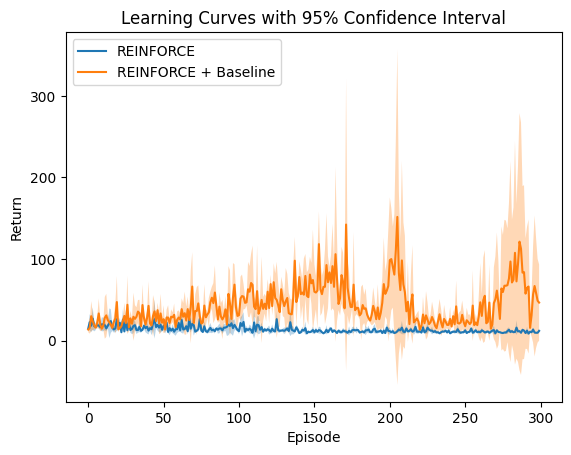

In [ ]:

def compute_stats(data):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])
    return mean, ci


mean_r, ci_r = compute_stats(reinforce_runs)
mean_b, ci_b = compute_stats(baseline_runs)

episodes = np.arange(num_episodes)

plt.figure()
plt.plot(episodes, mean_r, label="REINFORCE")
plt.fill_between(episodes, mean_r - ci_r, mean_r + ci_r, alpha=0.3)

plt.plot(episodes, mean_b, label="REINFORCE + Baseline")
plt.fill_between(episodes, mean_b - ci_b, mean_b + ci_b, alpha=0.3)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Learning Curves with 95% Confidence Interval")
plt.legend()
plt.show()

In [ ]:

def summarize_with_ci(data: np.ndarray):
    """
    data shape: (num_seeds, num_episodes)
    returns:
        mean curve, 95% confidence interval
    """
    mean_curve = np.mean(data, axis=0)

    # sample std (ddof=1 for unbiased estimate)
    sample_std = np.std(data, axis=0, ddof=1)

    num_runs = data.shape[0]
    standard_error = sample_std / np.sqrt(num_runs)

    ci_95 = 1.96 * standard_error

    return mean_curve, ci_95


mean_r, ci_r = summarize_with_ci(reinforce_runs)
mean_b, ci_b = summarize_with_ci(baseline_runs)

In [ ]:

last_seed = seed_list[-1]

policy_path = f"cartpole_policy_seed{last_seed}.pth"
value_path = f"cartpole_value_seed{last_seed}.pth"

torch.save(saved_policy.state_dict(), policy_path)
torch.save(saved_value_fn.state_dict(), value_path)

print("Saved:", policy_path)
print("Saved:", value_path)

Saved: cartpole_policy_seed2.pth
Saved: cartpole_value_seed2.pth
